In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [2]:
db_path = "../data/btc_prices.sqlite3"
conn = sqlite3.connect(db_path)

In [3]:
df = pd.read_sql_query("SELECT * FROM price_snapshots", conn)

In [4]:
df.head(40)

,id,asset,measurement_timestamp,filtered_timestamp,observed_market_type,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,...,midprice_filtered_timestamp,midprice_filtered_price,midprice_basis,microprice_1p5x_filtered_timestamp,microprice_1p5x_filtered_price,microprice_1p5x_basis,microprice_3x_filtered_timestamp,microprice_3x_filtered_price,microprice_3x_basis,recorded_at_ms
0,1,BTC,1774800195022,1774800195022,spot,BTC,66517.0,0.25839,66518.0,0.17042,...,1774800195022,66517.500000,11.000000,1774800195022,66517.602569,11.000017,1774800195022,66517.602564,11.000017,1774800195243
1,2,BTC,1774800195022,1774800195022,perp,BTC,66528.0,3.70558,66529.0,9.38021,...,1774800195022,66517.500000,11.000000,1774800195022,66517.602565,10.680612,1774800195022,66517.602556,10.680622,1774800195553
2,3,BTC,1774800195152,1774800195152,perp,BTC,66528.0,3.68066,66529.0,9.38021,...,1774800195152,66517.500000,11.000000,1774800195152,66517.602182,10.679641,1774800195152,66517.602174,10.679651,1774800195555
3,4,BTC,1774800195327,1774800195327,perp,BTC,66528.0,3.68066,66529.0,9.60567,...,1774800195327,66517.500000,11.000000,1774800195327,66517.600823,10.676241,1774800195327,66517.600816,10.676255,1774800195633
4,5,BTC,1774800195518,1774800195518,perp,BTC,66528.0,3.68066,66529.0,9.38021,...,1774800195518,66517.500000,11.000000,1774800195518,66517.602168,10.679605,1774800195518,66517.602158,10.679610,1774800195825
5,6,BTC,1774800195716,1774800195716,perp,BTC,66528.0,3.67766,66529.0,11.10994,...,1774800195716,66517.500000,11.000000,1774800195716,66517.592787,10.656147,1774800195716,66517.592785,10.656172,1774800196076
6,7,BTC,1774800195821,1774800195821,perp,BTC,66528.0,3.67466,66529.0,9.60567,...,1774800195821,66517.500000,11.000000,1774800195821,66517.600614,10.675718,1774800195821,66517.600588,10.675685,1774800196079
7,8,BTC,1774800195917,1774800195917,perp,BTC,66528.0,3.67466,66529.0,9.38021,...,1774800195917,66517.500000,11.000000,1774800195917,66517.602063,10.679341,1774800195917,66517.602050,10.679340,1774800196323
8,9,BTC,1774800196060,1774800196060,perp,BTC,66528.0,3.67466,66529.0,10.88448,...,1774800196060,66517.500000,11.000000,1774800196060,66517.593857,10.658822,1774800196060,66517.593857,10.658853,1774800196385
9,10,BTC,1774800196120,1774800196120,perp,BTC,66528.0,3.67466,66529.0,11.86194,...,1774800196120,66517.500000,11.000000,1774800196120,66517.589345,10.647539,1774800196120,66517.589344,10.647567,1774800196487


In [5]:
df = df.set_index("filtered_timestamp")

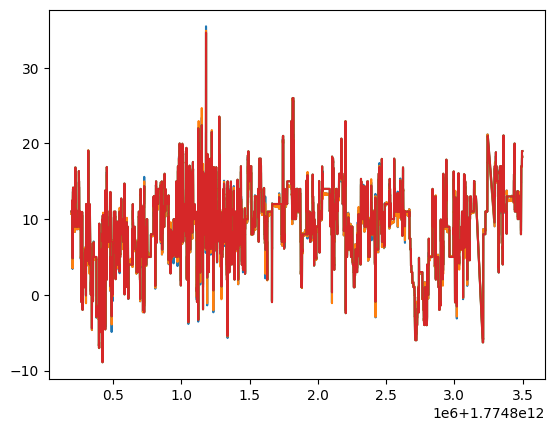

In [6]:
plt.plot(df.microprice_1p5x_basis)
plt.plot(df.microprice_3x_basis)
plt.plot(df.basis)
plt.plot(df.midprice_basis)

In [7]:
df.columns

Index(['id', 'asset', 'measurement_timestamp', 'observed_market_type',
       'observed_asset', 'observed_bid_price', 'observed_bid_size',
       'observed_ask_price', 'observed_ask_size', 'observed_mid_price',
       'observed_microprice', 'spot_price', 'perp_price', 'spot_microprice',
       'perp_microprice', 'filtered_price', 'basis',
       'midprice_filtered_timestamp', 'midprice_filtered_price',
       'midprice_basis', 'microprice_1p5x_filtered_timestamp',
       'microprice_1p5x_filtered_price', 'microprice_1p5x_basis',
       'microprice_3x_filtered_timestamp', 'microprice_3x_filtered_price',
       'microprice_3x_basis', 'recorded_at_ms'],
      dtype='object')

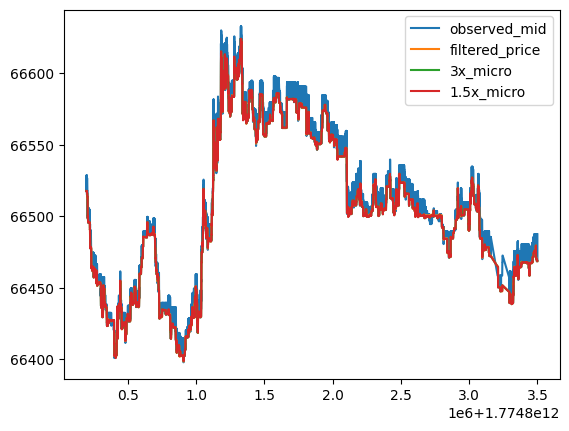

In [8]:
plt.plot(df.observed_mid_price, label="observed_mid")
plt.plot(df.filtered_price, label="filtered_price")
plt.plot(df.microprice_3x_filtered_price, label="3x_micro")
plt.plot(df.microprice_1p5x_filtered_price, label="1.5x_micro")
plt.legend()

In [11]:
plt.plot(df.raw_micro_spread - df.microprice_1p5x_basis)
plt.title("Raw micro spread - filtered microprice basis")

AttributeError: 'DataFrame' object has no attribute 'raw_micro_spread'

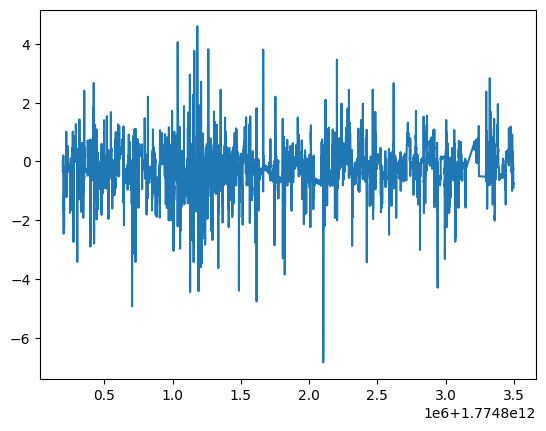

In [10]:
plt.plot(df.microprice_3x_basis - df.basis)